In [1]:
import os
import pandas as pd
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def tflog2pandas(path):
    runlog_data = pd.DataFrame()
    ea = event_accumulator.EventAccumulator(path)
    ea.Reload()

    tags = ea.Tags()['scalars']

    for tag in tags:
        event_list = ea.Scalars(tag)
        values = [e.value for e in event_list]
        steps = [e.step for e in event_list]
        tag_df = pd.DataFrame({tag: values, 'step': steps})
        
        if runlog_data.empty:
            runlog_data = tag_df
        else:
            runlog_data = pd.merge(runlog_data, tag_df, on="step", how="outer")

    return runlog_data


In [ ]:
# log_path = "../src/runs/rl/espov3/run8"
# log_path = "../src/runs/rl/final_large_runs/no_conditioning/run2"
log_path = "../src/runs/rl/final_large_runs/test/run5"
df = tflog2pandas(log_path)
df.index = range(len(df))

In [155]:
df = df.iloc[::2]  # reward was accidentally logged twice per epoch

In [5]:
df

,Components/legal_rate,step,Components/uniqueness_rate,Components/counter_intuitive_rate,Components/counter_intuitive_rate_given_unique,Components/unique_and_counter_intuitive,Components/entropy,Components/piece_counts,Components/dist_inter_fen,Components/dist_intra_fen,...,Components/all_dist,Components/pass_diversity_filtering,Components/move_match_rate,Components/cp_loss,Loss/Total Loss,Loss/RL Grad Norm,Loss/KL divergence,Loss/Clips,Loss/learning_rate,Reward
0,1.0000,0,0.0625,0.2500,0.0,0.0,0.622887,1.000000,14.000000,17.562500,...,0.437500,1.0,0.312500,0.0,0.0,0.576372,0.000000e+00,0.0,3.400000e-07,0.0
1,1.0000,1,0.1250,0.1250,0.0,0.0,0.581192,0.937500,13.937500,17.812500,...,0.562500,1.0,0.562500,0.0,0.0,0.545532,1.947496e-09,0.0,6.700000e-07,0.0
2,0.9375,2,0.0625,0.1875,0.0,0.0,0.668522,1.000000,13.733334,17.866667,...,0.400000,1.0,0.400000,0.0,0.0,0.664849,2.856027e-06,0.0,1.000000e-06,0.0
3,1.0000,3,0.3750,0.2500,0.0,0.0,0.583340,1.000000,15.687500,21.437500,...,0.187500,1.0,0.437500,0.0,0.0,0.550574,2.319569e-05,0.0,1.000000e-06,0.0
4,1.0000,4,0.2500,0.2500,0.0,0.0,0.611066,1.000000,13.875000,17.812500,...,0.187500,1.0,0.437500,0.0,0.0,0.617541,5.867185e-05,0.0,1.000000e-06,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1729,1.0000,1729,0.0625,0.1875,0.0,0.0,0.597613,0.937500,13.312500,16.750000,...,0.187500,1.0,0.312500,0.0,0.0,1.096554,8.217147e-01,0.0,1.000000e-06,0.0
1730,1.0000,1730,0.1875,0.1250,0.0,0.0,0.618948,1.000000,12.812500,15.562500,...,0.187500,1.0,0.562500,0.0,0.0,1.128288,3.807189e-01,0.0,1.000000e-06,0.0
1731,1.0000,1731,0.2500,0.4375,0.0,0.0,0.632367,0.937500,14.437500,18.687500,...,0.437500,1.0,0.562500,0.0,0.0,1.093830,2.835335e-01,0.0,1.000000e-06,0.0
1732,0.9375,1732,0.2500,0.1250,0.0,0.0,0.671674,0.933333,15.066667,19.666666,...,0.266667,1.0,0.466667,140.0,0.0,1.290976,6.031112e-01,0.0,1.000000e-06,0.0


In [4]:
def plot_rolling(col: pd.DataFrame, window=100):
    col.rolling(window=window, win_type='gaussian').mean(std=window / 4).plot(title=col.name)

def plot_ema(col, alpha=0.001, start=0):
    col.ewm(alpha=0.001).mean().iloc[start:].plot(title=col.name)

def plot_all(df: pd.DataFrame, *args, window=100, alpha=0.001, start=0, type="rolling"):
    for col in df:
        plt.figure()
        if type == "rolling":
            plot_rolling(df[col], window=window)
        elif type == "ema":
            plot_ema(df[col], alpha=alpha, start=start)
    plt.show()

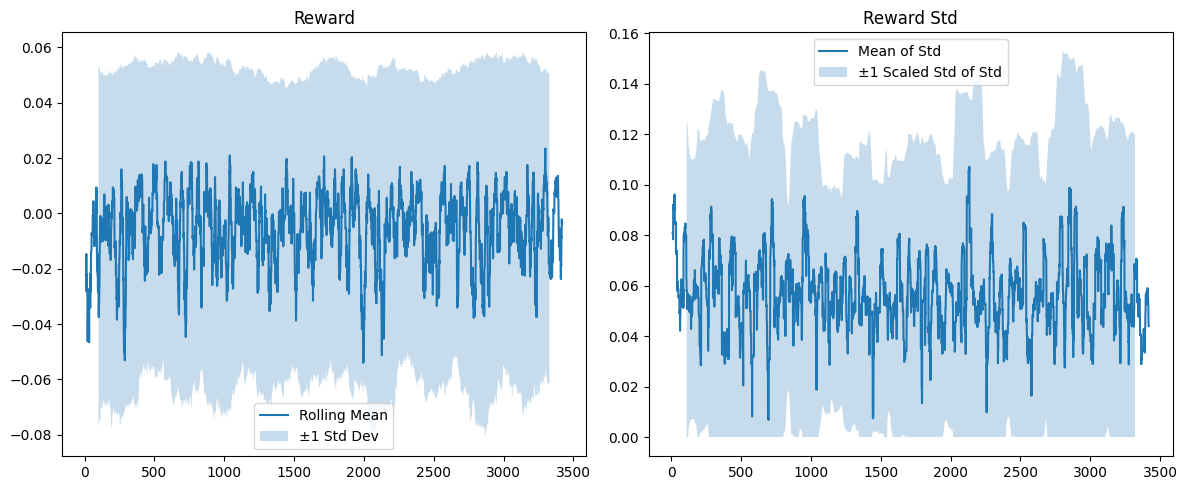

In [6]:
steps = df["step"]
col = df["Reward"]

plt.figure(figsize=(12, 5))

beta = 1
window_size = 20
slow_window = 10 * window_size

plt.subplot(1, 2, 1)
mean = col.rolling(window=window_size, center=True).mean()
std = col.rolling(window=slow_window, center=True).std()
std_mean = col.rolling(window=slow_window, center=True).mean()

plt.plot(steps, mean, label="Rolling Mean")
plt.fill_between(steps, std_mean - beta * std, std_mean + beta * std, alpha=0.25, label=f"±{beta} Std Dev")
plt.title("Reward")
plt.legend()

plt.subplot(1, 2, 2)
window_size = 20
# std_mean = col.rolling(window=window_size, center=True).std()
# std_std_mean = std_mean.rolling(window=10 * window_size, center=True).mean()
# std_std = std_mean.rolling(window=10 * window_size, center=True).std()
std_fast = col.rolling(window=window_size, center=True).std()
std_std_mean = std_fast.rolling(window=slow_window, center=True).mean()
std_std = std_fast.rolling(window=slow_window, center=True).std()
raw_std_std = std_std * np.sqrt(window_size)
lower_bound = np.maximum(0, std_std_mean - beta * raw_std_std)
upper_bound = std_std_mean + beta * raw_std_std

plt.plot(steps, std_fast, label="Mean of Std")
plt.fill_between(steps, lower_bound, upper_bound, alpha=0.25, label=f"±{beta} Scaled Std of Std")
plt.title("Reward Std")
plt.legend()

plt.tight_layout()
plt.show()

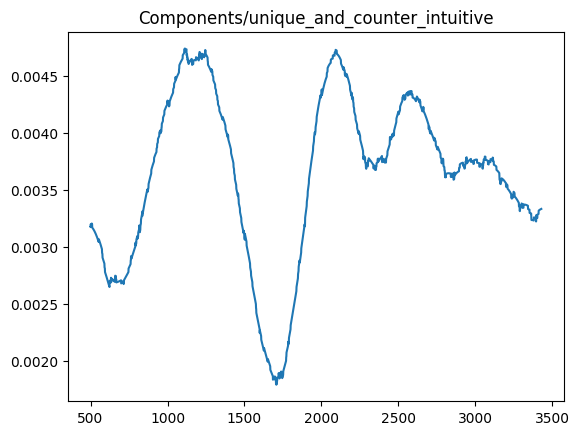

In [22]:
plot_rolling(df["Components/unique_and_counter_intuitive"], 500)

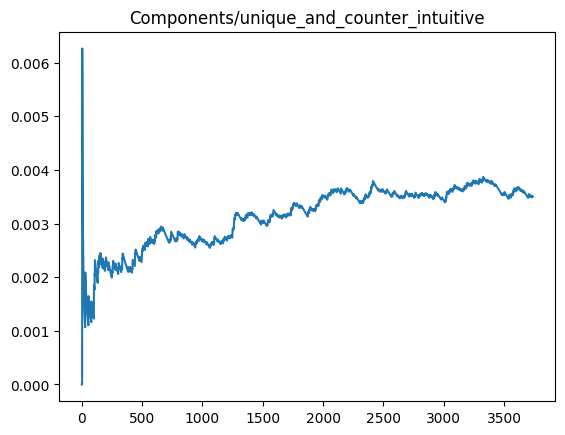

In [162]:
plot_ema(df["Components/unique_and_counter_intuitive"])

In [239]:
df.columns

Index(['Components/legal_rate', 'step', 'Components/uniqueness_rate',
       'Components/counter_intuitive_rate',
       'Components/counter_intuitive_rate_given_unique',
       'Components/unique_and_counter_intuitive', 'Components/entropy',
       'Components/piece_counts', 'Components/dist_inter_fen',
       'Components/dist_intra_fen', 'Components/dist_inter_pv',
       'Components/dist_intra_pv', 'Components/intra_dist',
       'Components/inter_dist', 'Components/all_dist',
       'Components/pass_diversity_filtering', 'Components/move_match_rate',
       'Components/cp_loss', 'Reward', 'Loss/Total Loss', 'Loss/RL Grad Norm',
       'Loss/KL divergence', 'Loss/Clips', 'Loss/learning_rate'],
      dtype='object')

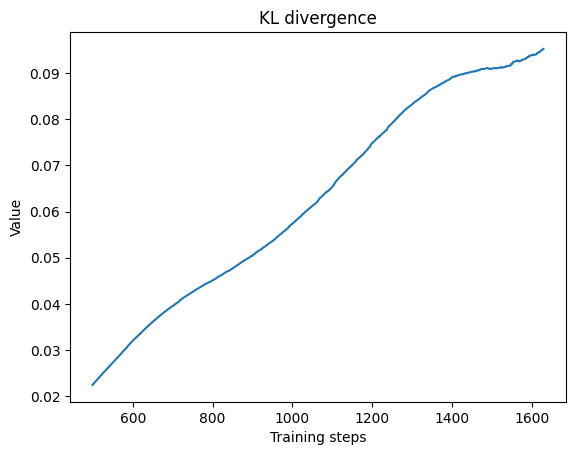

In [ ]:
plot_rolling(df["Loss/KL divergence"], window=500)
plt.title("KL divergence")
plt.xlabel("Training steps")
# plt.ylabel("Percentage of positions")
plt.ylabel("Value")
# plt.savefig("./slides/figures/kl_divergence.pdf")
plt.show()

C:\Users\aatus\AppData\Local\Temp\ipykernel_23300\2817206399.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


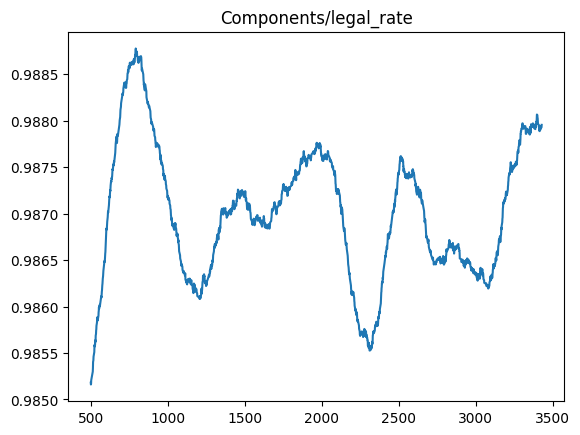

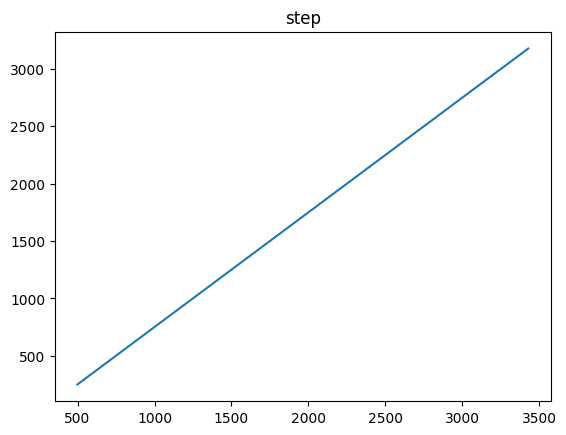

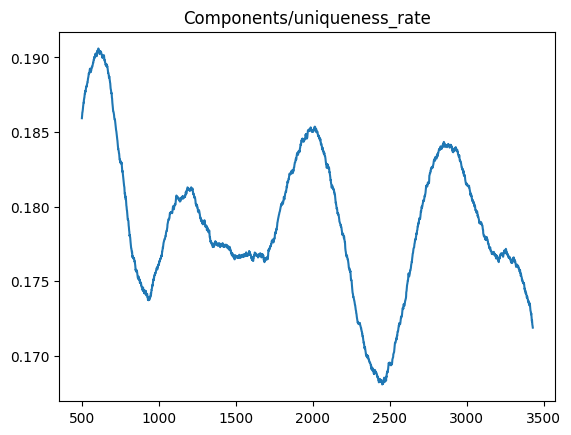

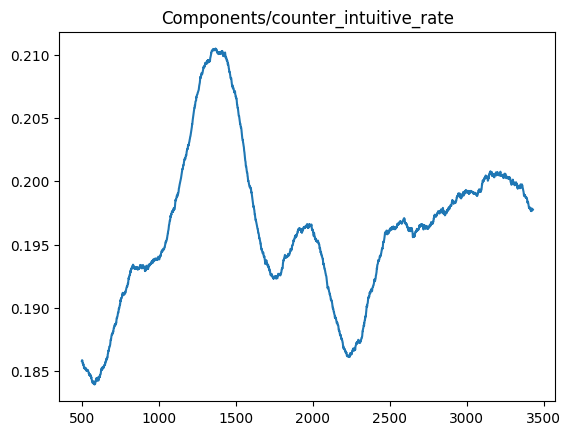

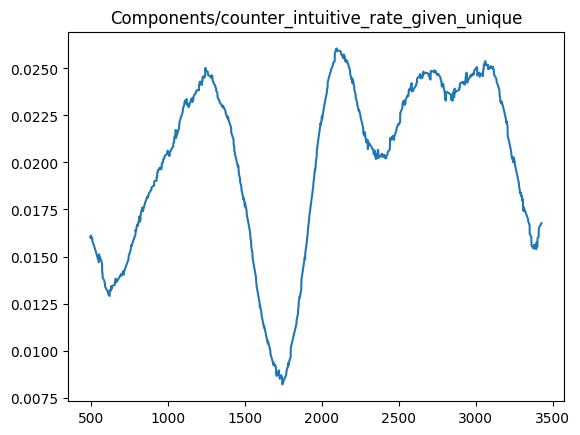

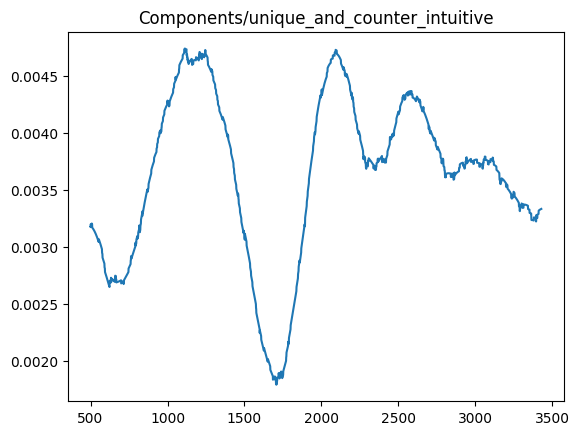

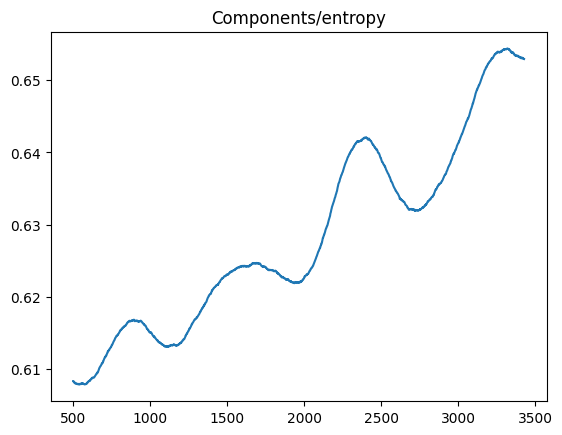

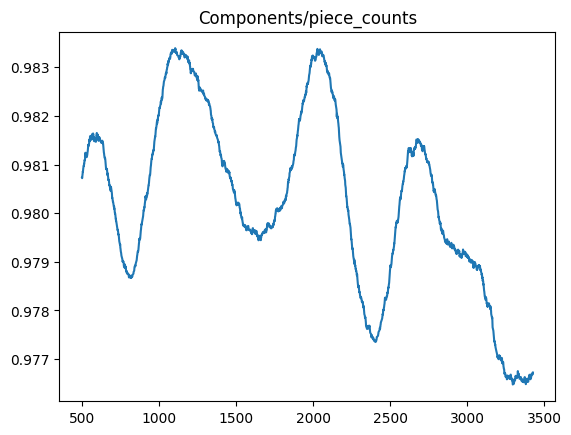

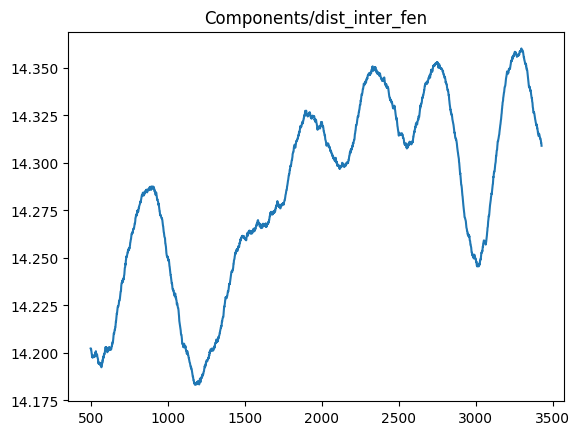

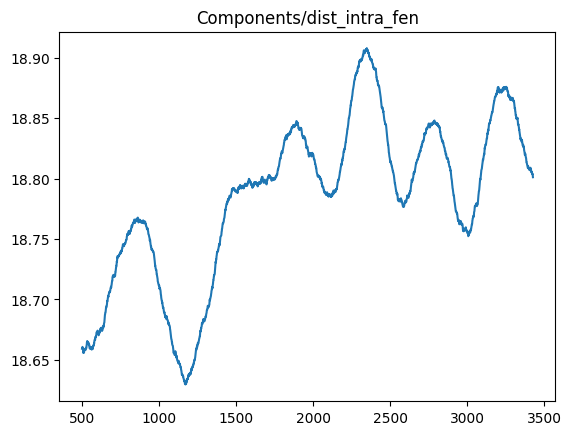

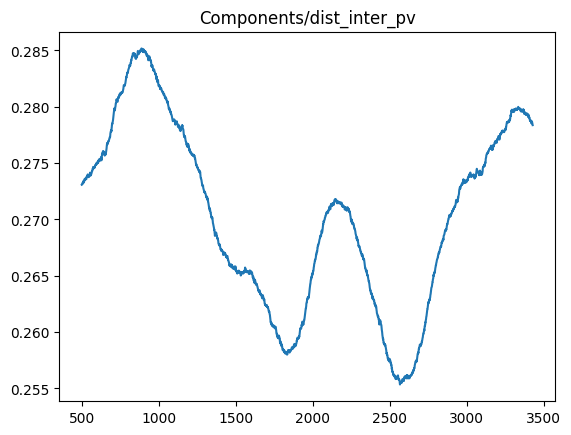

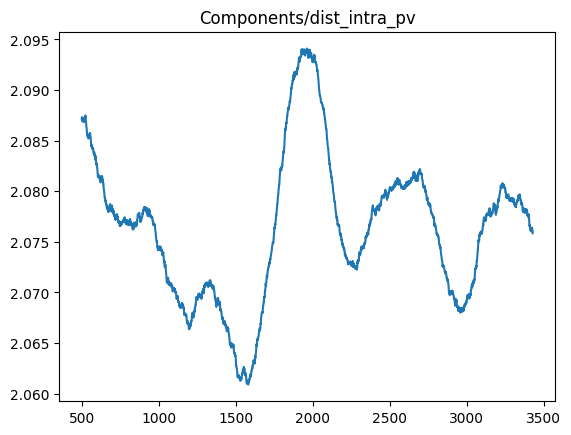

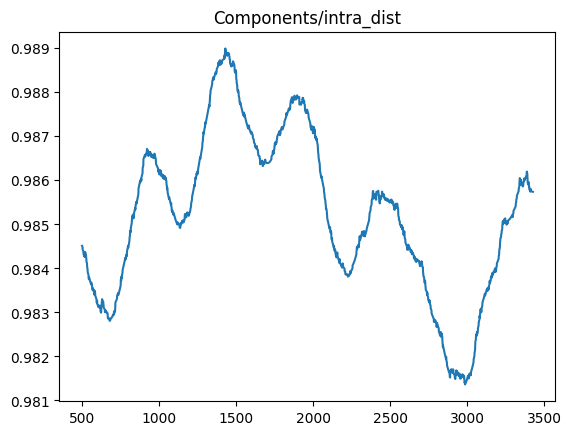

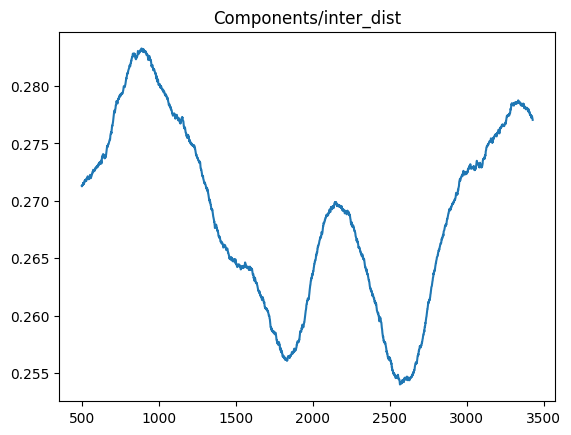

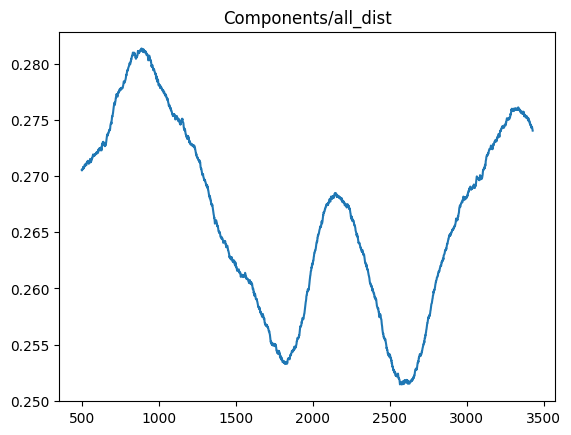

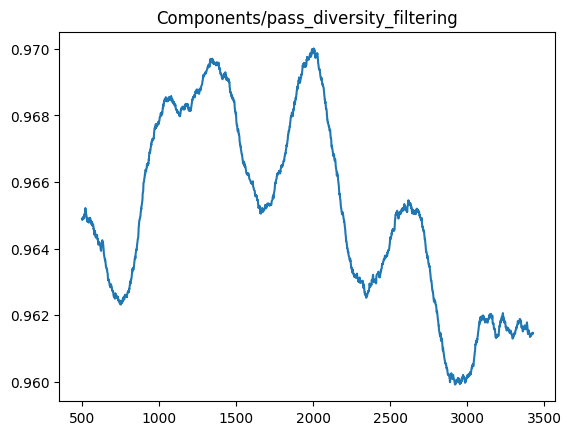

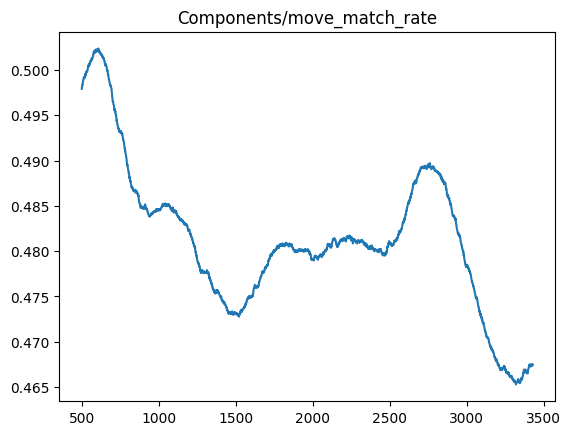

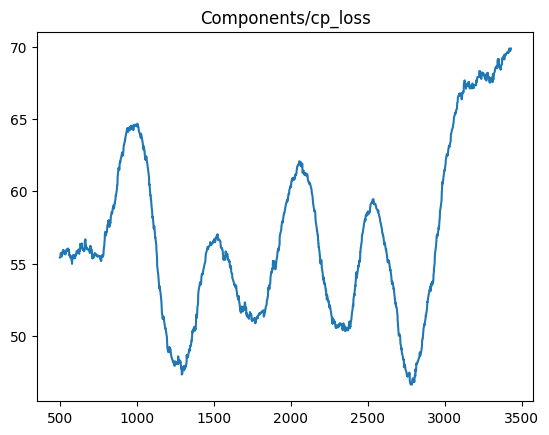

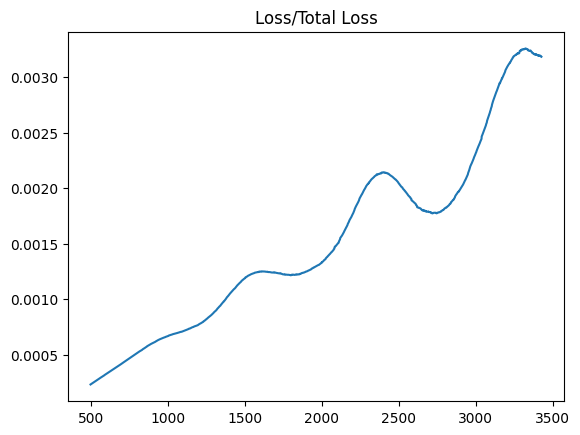

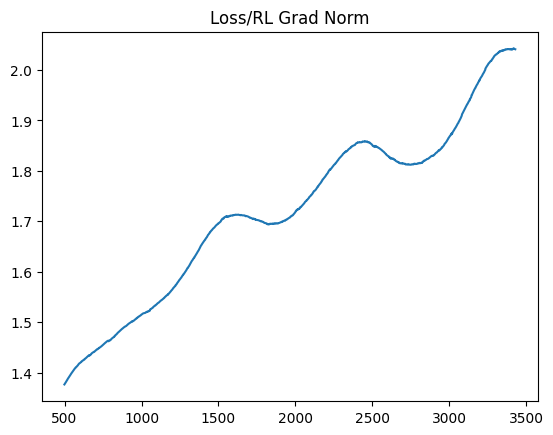

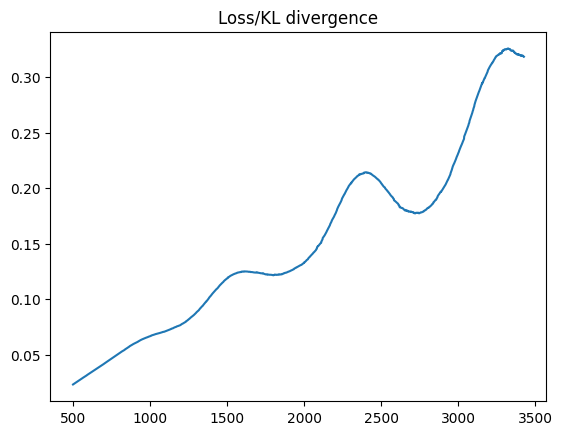

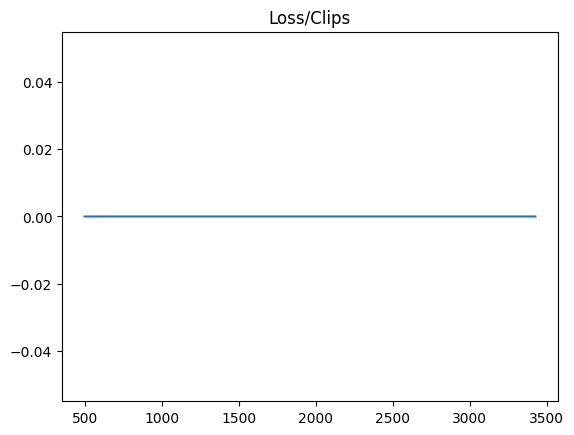

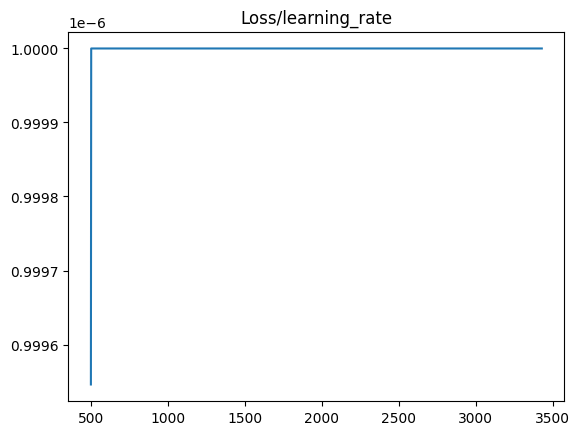

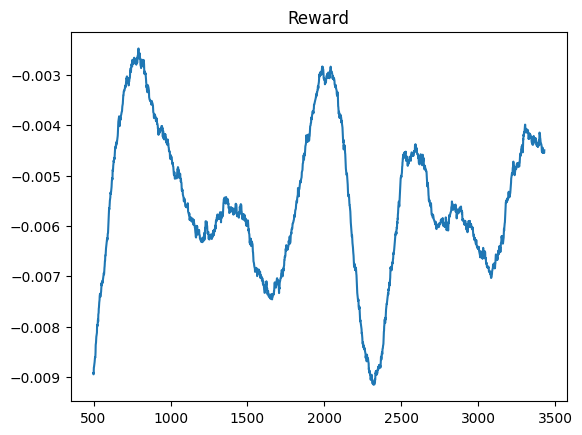

In [23]:
plot_all(df, window=500, type="rolling")